<a href="https://colab.research.google.com/github/melisms/techIstanbulBootcamp/blob/main/Oturum_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yapay Nöron


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
np.random.seed(42)

Bir öğrencinin haftalık çalışma saati ve günlük uyku saatinden sınavı geçme olasılığını tahmin eden bir nöron. Ağırlıkları şimdilik biz veriyoruz.

###Tek Nöron

In [ ]:
x = np.array([10,7])

w = np.array([0.4,0.3])
b = -5

z = np.dot(w,x)+b

In [ ]:
a = 1 / (1+np.exp(-z))

In [ ]:
print("Ağırlıklı toplam z :",round(z,2))

Ağırlıklı toplam z : 1.1


In [ ]:
print("Nöronun çıktısı a :",round(a,2))

Nöronun çıktısı a : 0.75


###Çoklu Nöron

In [ ]:
x = np.array([10,7])

w = np.array([[0.4,-0.2,0.1],
              [0.3,0.5,-0.1]
              ])
b = np.array([-5,-1,0])

z = x @ w + b

In [ ]:
a = 1 / (1+np.exp(-z))

In [ ]:
print("Ağırlık matrisinin boyutu : ",w.shape)
print("Katmanın toplamları z :",np.round(z,2))
print("Katmanın çıktıları a :",np.round(a,2))

Ağırlık matrisinin boyutu :  (2, 3)
Katmanın toplamları z : [1.1 0.5 0.3]
Katmanın çıktıları a : [0.75 0.62 0.57]


###Veri Hazırlığı

In [ ]:
import keras

(X_egitim, y_egitim), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Egitim verileri : ",X_egitim.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Egitim verileri :  (60000, 28, 28)


In [ ]:
X_egitim = X_egitim / 255
X_test = X_test / 255

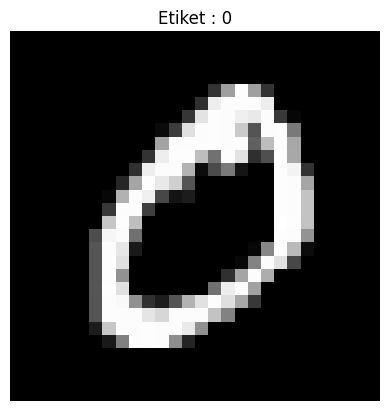

In [ ]:
plt.imshow(
    X_egitim[1],
    cmap='gray'
)
plt.title('Etiket : '+str(y_egitim[1]))
plt.axis('off')
plt.show()

###Model Oluşturulması

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(
        128,
        activation='relu',
    ),
    keras.layers.Dense(
        10,
        activation='softmax',
    ),
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(X_egitim,y_egitim,epochs=3,batch_size=128,validation_split=0.1)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8951 - loss: 0.3791 - val_accuracy: 0.9543 - val_loss: 0.1741
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9502 - loss: 0.1752 - val_accuracy: 0.9667 - val_loss: 0.1257
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9637 - loss: 0.1254 - val_accuracy: 0.9727 - val_loss: 0.1040


In [ ]:
kayip, dogruluk = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

In [ ]:
print("Test doğruluğu : %",round(dogruluk*100,1))

Test doğruluğu : % 96.5


#NLP

##Tokenizer

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

veri = [
    'Bu bir örnek cümle.',
    'Başka bir örnek cümle de var.',
    'Farklı bir örnek metin.'
]

In [ ]:
tokenizer1 = Tokenizer()

In [ ]:
tokenizer1.fit_on_texts(veri)

In [ ]:
sayisal_karsilik = tokenizer1.texts_to_sequences(veri)

In [ ]:
print('Kelimeye karsilik indeksleri : ',tokenizer1.word_index)

Kelimeye karsilik indeksleri :  {'bir': 1, 'örnek': 2, 'cümle': 3, 'bu': 4, 'başka': 5, 'de': 6, 'var': 7, 'farklı': 8, 'metin': 9}


In [ ]:
for sayi in sayisal_karsilik:
  print(sayi)

[4, 1, 2, 3]
[5, 1, 2, 3, 6, 7]
[8, 1, 2, 9]


In [ ]:
sabit_uzunluk = pad_sequences(sayisal_karsilik, maxlen=6)

In [ ]:
for sayi in sabit_uzunluk:
  print(sayi)

[0 0 4 1 2 3]
[5 1 2 3 6 7]
[0 0 8 1 2 9]


In [ ]:
from transformers import AutoTokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('openai-community/gpt2')

In [ ]:
for cumle in ['The students went to the library.','Öğrenciler kütüphaneye gittiler.']:
  idler = tokenizer.encode(cumle)
  parcalar = [tokenizer.decode(i) for i in idler]
  print(cumle)
  print('Token sayısı:',len(idler))
  print('Parçalar :',parcalar)
  print('ID ler :',idler)

The students went to the library.
Token sayısı: 7
Parçalar : ['The', ' students', ' went', ' to', ' the', ' library', '.']
ID ler : [464, 2444, 1816, 284, 262, 5888, 13]
Öğrenciler kütüphaneye gittiler.
Token sayısı: 17
Parçalar : ['�', '�', 'ğ', 'ren', 'cil', 'er', ' k', 'ü', 't', 'ü', 'ph', 'ane', 'ye', ' g', 'itt', 'iler', '.']
ID ler : [127, 244, 33133, 918, 2856, 263, 479, 9116, 83, 9116, 746, 1531, 5948, 308, 715, 5329, 13]


##Embedding

In [ ]:
from keras.layers import Embedding
import numpy as np

In [ ]:
giris_boyutu = len(tokenizer1.word_index) + 1

In [ ]:
boyut = 300

In [ ]:
embedding_katmani = Embedding(
    input_dim=giris_boyutu,
    output_dim=boyut,
    input_length=6
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
kimlikli_veri = embedding_katmani(np.array(sabit_uzunluk))

In [ ]:
print('Embedding katman sonucu : ')
print(kimlikli_veri)

Embedding katman sonucu : 
tf.Tensor(
[[[ 0.01142044 -0.02080729  0.03444172 ...  0.03759611  0.00065028
    0.00127071]
  [ 0.01142044 -0.02080729  0.03444172 ...  0.03759611  0.00065028
    0.00127071]
  [-0.03411118 -0.00927718  0.00098064 ...  0.00593967  0.03095608
    0.01131617]
  [ 0.04910648  0.04691062  0.00229915 ... -0.03723139 -0.04744059
    0.03771715]
  [ 0.00682073 -0.02182546 -0.04771979 ...  0.02858562 -0.01976556
    0.02281875]
  [ 0.00629944  0.01543656 -0.02068741 ... -0.04075664  0.03813355
   -0.03113568]]

 [[-0.02939451 -0.03012654  0.00462387 ... -0.00016633  0.0475052
    0.0038506 ]
  [ 0.04910648  0.04691062  0.00229915 ... -0.03723139 -0.04744059
    0.03771715]
  [ 0.00682073 -0.02182546 -0.04771979 ...  0.02858562 -0.01976556
    0.02281875]
  [ 0.00629944  0.01543656 -0.02068741 ... -0.04075664  0.03813355
   -0.03113568]
  [-0.04259859  0.01769562  0.03792414 ... -0.02323866  0.01308534
    0.03026659]
  [-0.03496795  0.01816412 -0.04684204 ... -0.01

In [ ]:
from sentence_transformers import SentenceTransformer
from sentence_transformers import util

In [ ]:
model_emb = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
cumleler = [
    "Kedi koltukta uyuyor.",
    "Kedicik kanepenin üstünde uyukluyor.",
    "Borsa bugün sert düştü.",
    "Hisse senetleri büyük değer kaybetti."
]

In [ ]:
vektorler = model_emb.encode(cumleler)
print("Vektörlerin boyutu :",vektorler.shape)

Vektörlerin boyutu : (4, 768)


In [ ]:
benzerlik = util.cos_sim(vektorler,vektorler)

In [ ]:
print("Kedi - kedi : ",round(float(benzerlik[0][1]),2))
print("Borsa - borsa : ",round(float(benzerlik[2][3]),2))
print("Kedi - borsa : ",round(float(benzerlik[0][2]),2))

Kedi - kedi :  0.62
Borsa - borsa :  0.64
Kedi - borsa :  -0.02


##Attention

In [ ]:
tokenlar = ["kedi","süt","içti"]

In [ ]:
Q = np.array([[2.0,0.0],
             [0.0,2.0],
             [2.0,2.0]]
             )
K = np.array([[2.0,0.0],
              [0.0,2.0],
              [0.0,0.0]
])


In [ ]:
puanlar = Q @ K.T / np.sqrt(2)

In [ ]:
agirliklar = np.exp(puanlar) / np.exp(puanlar).sum(axis=1,keepdims=True)

In [ ]:
print("Sütunlar : kedi, süt, içti")
for i in range(3):
  print(tokenlar[i], "------", np.round(agirliklar[i],2))

Sütunlar : kedi, süt, içti
kedi ------ [0.89 0.05 0.05]
süt ------ [0.05 0.89 0.05]
içti ------ [0.49 0.49 0.03]


##GPT2

In [ ]:
from transformers import AutoModelForCausalLM

In [ ]:
gpt2 = AutoModelForCausalLM.from_pretrained("openai-community/gpt2")

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
ayar = gpt2.config

In [ ]:
print("Transformer blok sayısı : ",ayar.n_layer)

Transformer blok sayısı :  12


In [ ]:
print("Dikkat(Attention) başlığı sayısı :",ayar.n_head)

Dikkat(Attention) başlığı sayısı : 12


In [ ]:
print("Embedding boyutu : ",ayar.n_embd)

Embedding boyutu :  768


In [ ]:
print("Sözlük boyutu : ",ayar.vocab_size)

Sözlük boyutu :  50257


In [ ]:
print("Bağlam penceresi : ",ayar.n_positions)

Bağlam penceresi :  1024


In [ ]:
parametre = gpt2.num_parameters()

In [ ]:
print("Toplam parametre : ", round(parametre / 1_000_000),"milyon")

Toplam parametre :  124 milyon


##Context window (bağlam penceresi)

In [ ]:
metin = "Derin öğrenme ve büyük dil modelleri." * 50

In [ ]:
token_sayisi = len(tokenizer.encode(metin))

##Metin üretimi

In [ ]:
import torch

In [ ]:
girdi = tokenizer("Every morning I drink a cup of",return_tensors="pt")

In [ ]:
with torch.no_grad():
  cikti = gpt2(**girdi)

In [ ]:
puanlar = cikti.logits[0,-1]

In [ ]:
olasiliklar = torch.softmax(puanlar,dim=0)

In [ ]:
en_iyi = torch.topk(olasiliklar,5)

In [ ]:
for olasilik,token_id in zip(en_iyi.values, en_iyi.indices):
  print(repr(tokenizer.decode(token_id)), '----- %',round(float(olasilik)*100),1)

' coffee' ----- % 47 1
' tea' ----- % 19 1
' water' ----- % 5 1
' milk' ----- % 2 1
' wine' ----- % 1 1


In [ ]:
metin = "Deep learning is"

In [ ]:
for adim in range(8):
  girdi = tokenizer(metin,return_tensors="pt")
  with torch.no_grad():
    puanlar = gpt2(**girdi).logits[0,-1]

  sonraki_id = torch.argmax(puanlar)
  metin = metin + tokenizer.decode(sonraki_id)
  print(adim + 1, ":",metin)

1 : Deep learning is a
2 : Deep learning is a very
3 : Deep learning is a very powerful
4 : Deep learning is a very powerful tool
5 : Deep learning is a very powerful tool for
6 : Deep learning is a very powerful tool for learning
7 : Deep learning is a very powerful tool for learning about
8 : Deep learning is a very powerful tool for learning about the


In [ ]:
girdi = tokenizer("Once upon a time,",return_tensors="pt")

In [ ]:
for sicaklik in [0.3,1.5]:
  torch.manual_seed(42)
  uretilen = gpt2.generate(
      **girdi,
      max_new_tokens=30,
      do_sample=True,
      temperature=sicaklik,
      pad_token_id=tokenizer.eos_token_id,

  )
  print("Sıcaklık",sicaklik, ":",tokenizer.decode(uretilen[0]))
  print()

Sıcaklık 0.3 : Once upon a time, I was a little bit of a girl. I was a little bit of a girl, but I was not a girl. I was a girl.

Sıcaklık 1.5 : Once upon a time, I would've given them the 'right' amount because, well, like a couple of these people it's really not. I always wanted them –



In [ ]:
soru = "What is the capital of Turkey?"

###GPT2

In [ ]:
girdi = tokenizer("Question: "+soru+"\nAnswer:",return_tensors="pt")

In [ ]:
uretilen = gpt2.generate(
    **girdi,
    max_new_tokens=25,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id
)

In [ ]:
print("GPT-2 (temel model):")
print(tokenizer.decode(uretilen[0]))
print()

GPT-2 (temel model):
Question: What is the capital of Turkey?
Answer: The capital of Turkey is the capital of the Republic of Turkey.
The capital of Turkey is the capital of the Republic of



###Sohbet modeli Qwen2.5

In [ ]:
sohbet_adi = "Qwen/Qwen2.5-0.5B-Instruct"
sohbet_tok = AutoTokenizer.from_pretrained(sohbet_adi)
sohbet_model = AutoModelForCausalLM.from_pretrained(
    sohbet_adi,
    dtype=torch.float32,
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
mesajlar = [{"role":"user","content":soru}]

In [ ]:
metin = sohbet_tok.apply_chat_template(
    mesajlar,
    tokenize=False,
    add_generation_prompt=True
)

In [ ]:
girdi = sohbet_tok(metin, return_tensors="pt")
uretilen = sohbet_model.generate(
    **girdi,
    max_new_tokens=40,
    do_sample=False
)

In [ ]:
soru_uzunlugu = len(girdi["input_ids"][0])
cevap = uretilen[0][soru_uzunlugu:]


In [ ]:
print("Qwen (sohbet modeli) : ")
print(sohbet_tok.decode(cevap, skip_special_tokens=True))

Qwen (sohbet modeli) : 
The capital of Turkey is Ankara.


#Uygulama

In [ ]:
ornekler = {
    "Fatura ve ödeme": [
        "Faturam neden bu kadar yüksek geldi?",
        "Kredi kartımdan iki kez ödeme alınmış.",
        "Ödeme yaparken hata alıyorum.",
        "Faturamı nereden görebilirim?",
        "Otomatik ödeme talimatı vermek istiyorum.",
        "Geçen ayın faturası hâlâ ödenmemiş görünüyor.",
        "Taksitli ödeme yapabilir miyim?",
        "Fatura adresimi değiştirmek istiyorum.",
    ],
    "Teknik destek": [
        "İnternetim sürekli kopuyor.",
        "Uygulama açılmıyor, hata veriyor.",
        "Şifremi unuttum, giriş yapamıyorum.",
        "Modemin ışıkları yanıp sönüyor.",
        "Mobil uygulama çok yavaş çalışıyor.",
        "Hesabıma giriş yaparken doğrulama kodu gelmiyor.",
        "Wi-Fi bağlantım çok zayıf.",
        "Güncellemeden sonra uygulama çöktü.",
    ],
    "Kargo ve teslimat": [
        "Siparişim hâlâ gelmedi.",
        "Kargom nerede?",
        "Teslimat adresini değiştirebilir miyim?",
        "Paket hasarlı geldi.",
        "Kargo takip numarası çalışmıyor.",
        "Siparişim yanlış adrese gitmiş.",
        "Teslimat ne zaman yapılacak?",
        "Kurye kapıya gelmeden gitmiş.",
    ],
    "İade ve iptal": [
        "Ürünü iade etmek istiyorum.",
        "Siparişimi iptal edebilir miyim?",
        "İade param ne zaman yatar?",
        "Aldığım ürün beden olarak olmadı.",
        "Aboneliğimi iptal etmek istiyorum.",
        "Ürün açıklamadaki gibi değil, geri göndereceğim.",
        "İade kargosu ücretli mi?",
        "Yanlış ürün geldi, değiştirmek istiyorum.",
    ],
}

In [ ]:
departmanlar = list(ornekler)

In [ ]:
metinler = []
etiketler = []

In [ ]:
for numara, departman in enumerate(departmanlar):
  for mesaj in ornekler[departman]:
    metinler.append(mesaj)
    etiketler.append(numara)

In [ ]:
print("Toplam mesaj : ",len(metinler))
print("Departmanlar : ",departmanlar)

Toplam mesaj :  32
Departmanlar :  ['Fatura ve ödeme', 'Teknik destek', 'Kargo ve teslimat', 'İade ve iptal']


In [ ]:
X = model_emb.encode(metinler)
y = np.array(etiketler)

print("X boyutu : ",X.shape)
print("y boyutu : ",y.shape)

X boyutu :  (32, 768)
y boyutu :  (32,)


In [ ]:
import keras
keras.utils.set_random_seed(42)

In [ ]:
siniflandirici = keras.Sequential([
    keras.Input(shape=(768,)),
    keras.layers.Dense(
        32,
        activation="relu"
    ),
    keras.layers.Dense(
        4,
        activation="softmax"
    )
])

In [ ]:
siniflandirici.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
gecmis = siniflandirici.fit(
    X,
    y,
    epochs=60,
    verbose=0
)

In [ ]:
def yonlendir(mesaj):
  vektor = model_emb.encode([mesaj])
  olasiliklar = siniflandirici.predict(vektor,verbose=0)[0]
  en_iyi = np.argmax(olasiliklar)
  guven = round(float(olasiliklar[en_iyi])*100)
  return departmanlar[en_iyi],guven

In [ ]:
yeni_mesajlar = [
    "Bu ay faturama fazladan ücret yansımış.",
    "Telefonumdaki uygulama sürekli kapanıyor.",
    "Paketim üç gündür yolda, ne zaman gelir?",
    "Siparişimden vazgeçtim.",
    "Hesabım kilitlendi."
]

In [ ]:
for mesaj in yeni_mesajlar:
  departman,guven = yonlendir(mesaj)
  print(mesaj,"----",departman,"------ güven : %",guven)

Bu ay faturama fazladan ücret yansımış. ---- Fatura ve ödeme ------ güven : % 93
Telefonumdaki uygulama sürekli kapanıyor. ---- Teknik destek ------ güven : % 96
Paketim üç gündür yolda, ne zaman gelir? ---- Kargo ve teslimat ------ güven : % 80
Siparişimden vazgeçtim. ---- İade ve iptal ------ güven : % 93
Hesabım kilitlendi. ---- Teknik destek ------ güven : % 82


In [ ]:
mesaj = input("mesaj giriniz : ")

departman, guven = yonlendir(mesaj)
print("Mesaj :",mesaj)
print("Departman : ",departman)
print("Güven : %",guven)

mesaj giriniz : Kargomu komşuya bırakmışlar, ama komşum bende yok diyor. Peki bu kargo kimde?
Mesaj : Kargomu komşuya bırakmışlar, ama komşum bende yok diyor. Peki bu kargo kimde?
Departman :  Kargo ve teslimat
Güven : % 84
